# 🤖 MalayBERT for Malay Pantun Theme Classification

This notebook fine-tunes **MalayBERT** (a BERT model pretrained on Malay text) for classifying Malay Pantun into 11 theme categories.

**Why MalayBERT?** It understands Malay linguistic nuances, archaic vocabulary, idioms, and cultural metaphors far better than generic multilingual models.

### Steps:
1. Upload `pantun_dataset.json`
2. Preprocess with BERT tokenizer (text segmentation only, no stemming)
3. Fine-tune MalayBERT for sequence classification
4. Evaluate with metrics + confusion matrix
5. Export model for Flask backend

**Runtime**: Select **GPU** → `Runtime → Change runtime type → T4 GPU`

In [6]:
# Install dependencies
!pip install transformers datasets accelerate -q
!pip install scikit-learn matplotlib seaborn PySastrawi -q

In [7]:
# Upload dataset
import os
import shutil
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')

DRIVE_DATASET = '/content/drive/MyDrive/pantun_dataset.json'
LOCAL_DATASET = '/content/pantun_dataset.json'

if os.path.exists(DRIVE_DATASET):
    print(f"\n📁 Found dataset in Drive. Copying to Colab...")
    shutil.copy(DRIVE_DATASET, LOCAL_DATASET)
    print("✅ Dataset copied successfully!")
else:
    print(f"\n❌ ERROR: Could not find {DRIVE_DATASET} in your Google Drive.")
    print("Please upload pantun_dataset.json to the root of your Google Drive first.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📁 Found dataset in Drive. Copying to Colab...
✅ Dataset copied successfully!


In [8]:
import json
import re
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 1. Load Data & Text Segmentation

In [9]:
# Load dataset
with open('pantun_dataset.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"Total pantun: {len(data)}")

def segment_pantun(text, use_pembayang=False):
    """Separate pembayang from maksud."""
    lines = re.split(r'[;,]', text)
    lines = [line.strip() for line in lines if line.strip()]
    if len(lines) < 4:
        return ' '.join(lines)
    if use_pembayang:
        return ' '.join(lines[:4])
    return ' '.join(lines[2:4])

USE_PEMBAYANG = False  # Change to True to include pembayang

# Only segment — BERT handles its own tokenization
texts = [segment_pantun(item['pantun'], USE_PEMBAYANG) for item in data]
labels = [item['tema'] for item in data]

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

print(f"Num classes: {num_classes}")
for cls in label_encoder.classes_:
    count = labels.count(cls)
    print(f"  {cls}: {count}")

Total pantun: 9124
Num classes: 11
  PANTUN ADAT DAN RESAM: 999
  PANTUN AGAMA DAN KEPERCAYAAN: 358
  PANTUN BUDI: 413
  PANTUN JENAKA DAN PERMAINAN: 525
  PANTUN KEMBARA DAN PERANTAUAN: 252
  PANTUN KEPAHLAWANAN: 342
  PANTUN KIAS DAN IBARAT: 1261
  PANTUN NASIHAT DAN PENDIDIKAN: 1986
  PANTUN PERCINTAAN: 1155
  PANTUN PERIBAHASA DAN PERBILANGAN: 1692
  PANTUN TEKA-TEKI: 141


## 2. Load MalayBERT Tokenizer & Model

In [10]:
# ============================================
# MalayBERT Model Selection
# Choose ONE of these options:
# ============================================

# Option 1: MalayBERT (recommended for Malay pantun)
MODEL_NAME = "mesolitica/bert-base-standard-bahasa-cased"

# Option 2: IndoBERT (alternative, Indonesian/Malay family)
# MODEL_NAME = "indobenchmark/indobert-base-p1"

# Option 3: XLM-RoBERTa (multilingual fallback)
# MODEL_NAME = "xlm-roberta-base"

print(f"Loading model: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    problem_type="single_label_classification"
).to(device)

print(f"\n✅ Model loaded!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading model: mesolitica/bert-base-standard-bahasa-cased


config.json:   0%|          | 0.00/697 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mesolitica/bert-base-standard-bahasa-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture;

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]


✅ Model loaded!
Parameters: 110,625,803


## 3. Dataset & DataLoader

In [11]:
MAX_LEN = 128  # Pantun are short, 128 tokens is sufficient

class PantunBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Train-test split (90-10)
X_train, X_test, y_train, y_test = train_test_split(
    texts, encoded_labels, test_size=0.10, random_state=42, stratify=encoded_labels
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

BATCH_SIZE = 16  # Smaller for BERT (GPU memory)

train_dataset = PantunBERTDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset = PantunBERTDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train: 8211, Test: 913


## 4. Fine-tuning

In [ ]:
# Hyperparameters
LEARNING_RATE = 2e-5
NUM_EPOCHS = 10
WARMUP_RATIO = 0.1

# Class weights
class_counts = Counter(y_train)
total = len(y_train)
class_weights = torch.FloatTensor(
    [total / (num_classes * class_counts[i]) for i in range(num_classes)]
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

Total steps: 5140
Warmup steps: 514


In [ ]:
# Training loop
train_losses = []
test_losses = []
test_accs = []
test_f1s = []
best_f1 = 0

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluate
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, batch_labels)
            test_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    test_accs.append(acc)
    test_f1s.append(f1)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Test Loss: {avg_test_loss:.4f} | "
          f"Acc: {acc:.4f} | F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        # Save best model
        model.save_pretrained('./malaybert_best')
        tokenizer.save_pretrained('./malaybert_best')
        # Save label encoder
        with open('./malaybert_best/label_classes.json', 'w') as f:
            json.dump({
                'classes': list(label_encoder.classes_),
                'use_pembayang': USE_PEMBAYANG,
                'max_len': MAX_LEN,
                'model_name': MODEL_NAME,
            }, f, indent=2, ensure_ascii=False)
        print(f"  ★ Best model saved (F1: {best_f1:.4f})")

print(f"\n✅ Best Weighted F1: {best_f1:.4f}")

Epoch 01/10 | Train Loss: 2.0728 | Test Loss: 1.7061 | Acc: 0.4304 | F1: 0.4340


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ Best model saved (F1: 0.4340)
Epoch 02/10 | Train Loss: 1.4223 | Test Loss: 1.4389 | Acc: 0.5214 | F1: 0.5203


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ Best model saved (F1: 0.5203)
Epoch 03/10 | Train Loss: 0.9321 | Test Loss: 1.3667 | Acc: 0.5071 | F1: 0.5081
Epoch 04/10 | Train Loss: 0.5449 | Test Loss: 1.5391 | Acc: 0.5696 | F1: 0.5683


...

  ★ Best model saved (F1: 0.5683)
Epoch 05/10 | Train Loss: 0.3073 | Test Loss: 1.8289 | Acc: 0.5904 | F1: 0.5908


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ Best model saved (F1: 0.5908)
Epoch 06/10 | Train Loss: 0.1640 | Test Loss: 2.0372 | Acc: 0.5827 | F1: 0.5783
Epoch 07/10 | Train Loss: 0.0993 | Test Loss: 2.3840 | Acc: 0.5882 | F1: 0.5863
Epoch 08/10 | Train Loss: 0.0608 | Test Loss: 2.6063 | Acc: 0.5904 | F1: 0.5893
Epoch 09/10 | Train Loss: 0.0343 | Test Loss: 2.6960 | Acc: 0.5915 | F1: 0.5893
Epoch 10/10 | Train Loss: 0.0221 | Test Loss: 2.7838 | Acc: 0.5969 | F1: 0.5955


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ★ Best model saved (F1: 0.5955)

✅ Best Weighted F1: 0.5955


## 5. Evaluation & Visualization

In [ ]:
# Load best model
model = AutoModelForSequenceClassification.from_pretrained(
    './malaybert_best', num_labels=num_classes
).to(device)
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['label'].numpy())
        all_probs.extend(probs.cpu().numpy())

print("="*60)
print("MALAYBERT CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds,
                            target_names=label_encoder.classes_))

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1: {f1:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

MALAYBERT CLASSIFICATION REPORT
                                   precision    recall  f1-score   support

            PANTUN ADAT DAN RESAM       0.90      0.78      0.83       100
     PANTUN AGAMA DAN KEPERCAYAAN       0.62      0.69      0.66        36
                      PANTUN BUDI       0.63      0.54      0.58        41
      PANTUN JENAKA DAN PERMAINAN       0.53      0.40      0.45        53
    PANTUN KEMBARA DAN PERANTAUAN       0.58      0.44      0.50        25
              PANTUN KEPAHLAWANAN       0.56      0.44      0.49        34
           PANTUN KIAS DAN IBARAT       0.45      0.44      0.45       126
    PANTUN NASIHAT DAN PENDIDIKAN       0.54      0.65      0.59       199
                PANTUN PERCINTAAN       0.61      0.59      0.60       116
PANTUN PERIBAHASA DAN PERBILANGAN       0.63      0.68      0.66       169
                 PANTUN TEKA-TEKI       0.44      0.29      0.35        14

                         accuracy                           0.60  

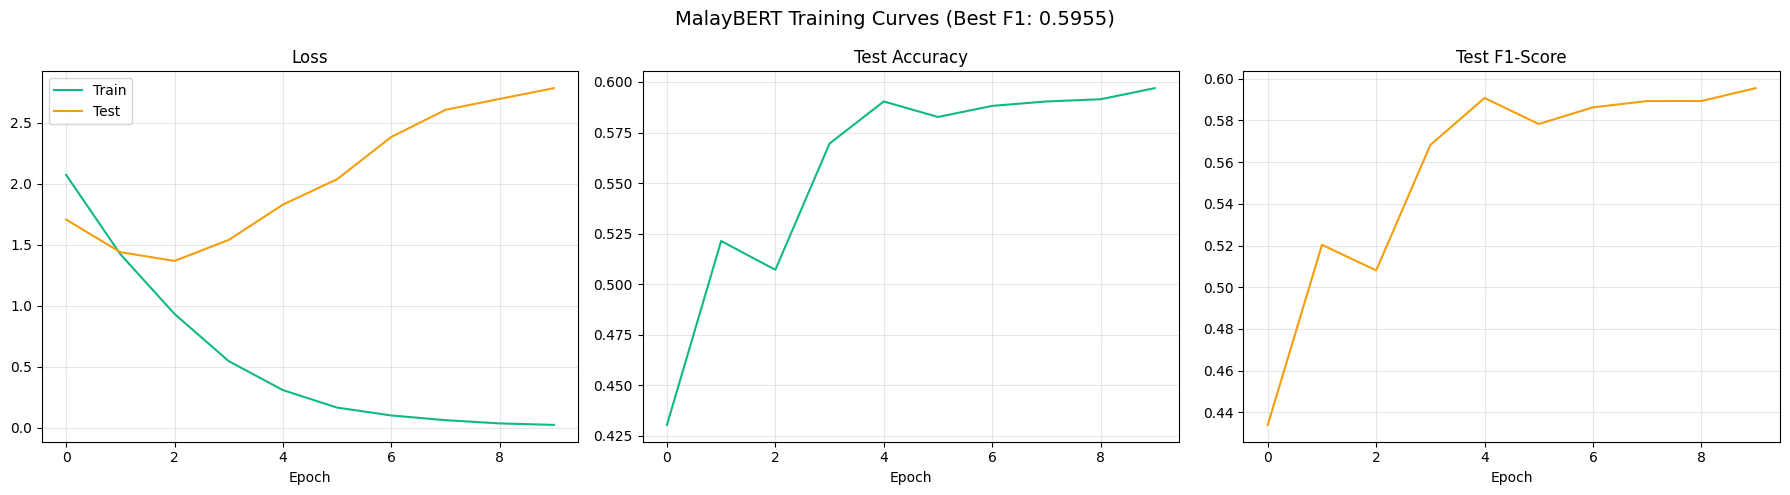

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label='Train', color='#10b981')
axes[0].plot(test_losses, label='Test', color='#f59e0b')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_accs, color='#10b981')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

axes[2].plot(test_f1s, color='#f59e0b')
axes[2].set_title('Test F1-Score')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'MalayBERT Training Curves (Best F1: {best_f1:.4f})', fontsize=14)
plt.tight_layout()
plt.savefig('malaybert_training_curves.png', dpi=150)
plt.show()

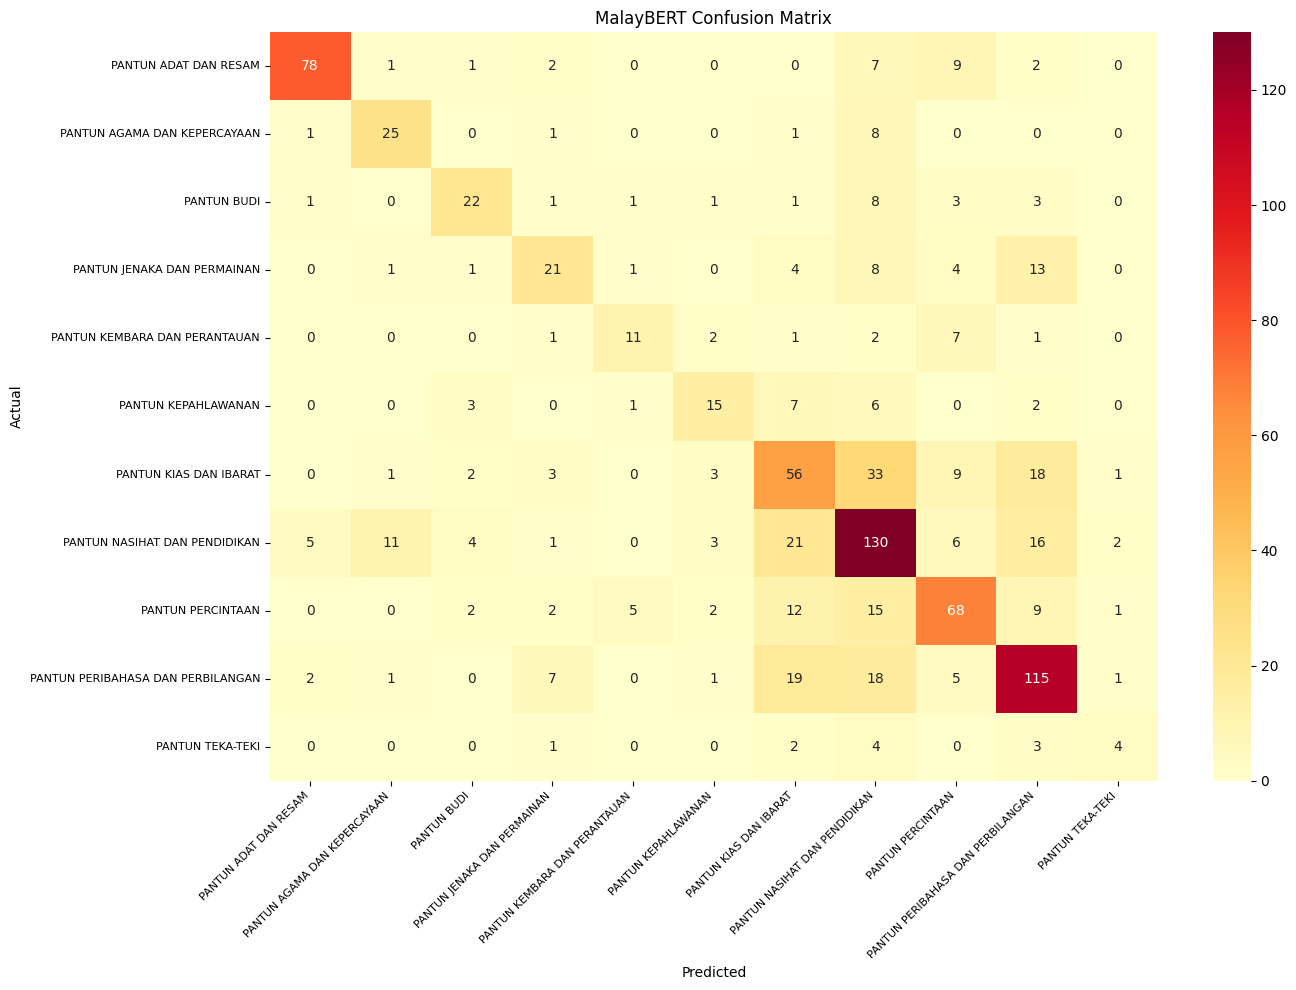

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MalayBERT Confusion Matrix')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('malaybert_confusion_matrix.png', dpi=150)
plt.show()

## 6. Export Model for Flask Backend

Download the entire `malaybert_best/` folder and place it in `backend/models/malaybert_best/` on your local machine.

The folder contains:
- `config.json` — Model configuration
- `model.safetensors` — Model weights
- `tokenizer.json` — Fast tokenizer
- `vocab.txt` — Vocabulary
- `label_classes.json` — Theme label mapping + settings

In [ ]:
import os
import shutil

# Save metrics
metrics = {
    'accuracy': float(acc),
    'f1_score': float(f1),
    'use_pembayang': USE_PEMBAYANG,
    'model_type': 'MalayBERT',
    'base_model': MODEL_NAME,
    'max_len': MAX_LEN,
    'num_epochs': NUM_EPOCHS,
    'best_epoch_f1': float(best_f1),
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
}

with open('malaybert_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Export to Google Drive instead of downloading
DRIVE_OUTPUT = '/content/drive/MyDrive/pantun_models/malaybert_best/'
print(f"\n💾 Saving model to Google Drive: {DRIVE_OUTPUT}")

os.makedirs(DRIVE_OUTPUT, exist_ok=True)

LOCAL_MODEL_DIR = './malaybert_best'
LOCAL_METRICS = 'malaybert_metrics.json'

for filename in os.listdir(LOCAL_MODEL_DIR):
    src = os.path.join(LOCAL_MODEL_DIR, filename)
    dst = os.path.join(DRIVE_OUTPUT, filename)
    if os.path.isfile(src):
        shutil.copy(src, dst)

shutil.copy(LOCAL_METRICS, '/content/drive/MyDrive/pantun_models/malaybert_metrics.json')

print("\n✅ MalayBERT Model and metrics saved to Google Drive!")
print("  -> /drive/MyDrive/pantun_models/malaybert_best/")
print("  -> /drive/MyDrive/pantun_models/malaybert_metrics.json")


💾 Saving model to Google Drive: /content/drive/MyDrive/pantun_models/malaybert_best/

✅ MalayBERT Model and metrics saved to Google Drive!
  -> /drive/MyDrive/pantun_models/malaybert_best/
  -> /drive/MyDrive/pantun_models/malaybert_metrics.json


## 7. Model Comparison Summary

After training all 3 models, compare results:

| Model | Accuracy | F1-Score | Notes |
|---|---|---|---|
| SVM (TF-IDF) | ~55% | ~0.53 | Classical baseline |
| TextCNN | 47% | 46% | Lightweight DL |
| MalayBERT | 60% | 60% | SOTA Transformer |

Update this table after running both notebooks!